### Muerte súbita - proyectos legislativos

Para controlar la visualizacion usar:
* https://www.color-blindness.com/coblis-color-blindness-simulator/
* https://colorbrewer2.org/#type=diverging&scheme=BrBG&n=3

In [1]:
# Cargar las librerías necesarias
from dotenv import load_dotenv
import pandas as pd
import pickle 
import os
import sys
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
load_dotenv() 

True

In [2]:
HEALTH_CYAN = "#0077A8"   # celeste medio
GRAY_MAIN   = "#8F8F8F"
GRAY_LIGHT  = "#E0E0E0"
GRAY_DARK   = "#3A3A3A"

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import locale

#locale.setlocale(locale.LC_ALL, 'es_AR.UTF-8')
#'es_ES.UTF-8'
#'es_ES'
#'spanish'

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette=[HEALTH_CYAN, GRAY_MAIN, GRAY_LIGHT, GRAY_DARK]
)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "font.size": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.edgecolor": "#2B2B2B",
    "axes.labelcolor": "#2B2B2B",
    "text.color": "#2B2B2B",
    "grid.color": "#E5E5E5",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "legend.fontsize": 18,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})


### Lectura de datos


In [4]:
# Configurar path
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno
sys.path.append(BASE_DIR)
sys.path.append(RESULTADOS_DIR)

pd.set_option('display.max_colwidth', None)

In [5]:
#Se saca 'vivir','morir','capacitar','capacita'

In [6]:
ms_palabras = ['muerte_subita' ,'desfibrilador','desfibracion','cardiovascular','cardioasistido','dea','dispositivo', 'muerte','vida','capacitacion', 'emergencia','supervivencia','reanimacion','prevencion','incidencia','deportivo']


In [7]:
print("Cantidad de palabras asociadas:",len(ms_palabras))

Cantidad de palabras asociadas: 16


#### Texto

In [8]:
# Abrir
with open(RESULTADOS_DIR+'proyecto_2009_2024_LIMPIO2_df.pkl', 'rb') as file:
    total_df = pickle.load(file)

total_df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Proyecto.ID,92535,92535,HCDN186242,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título,92535,89835,JUICIO POR JURADOS. CREACION.,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Publicación.Fecha,92535,NaN,NaN,NaN,2016-02-26 22:02:05.349327104,2009-03-02 00:00:00,2012-08-02 00:00:00,2015-12-03 00:00:00,2019-08-28 00:00:00,2024-02-29 00:00:00,NaN
Publicación.ID,91847,3021,HCDN127TP001,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Exp..Diputados,92535,92535,0001-D-2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tipo,92535,5,RESOLUCION,41840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Max_Orden,92535.0,NaN,NaN,NaN,1.543438,1.0,1.0,1.0,2.0,8.0,0.791713
Proyecto_girado_a_comisiones_SALUD,92535.0,NaN,NaN,NaN,0.108251,0.0,0.0,0.0,0.0,1.0,0.310699
Proyecto_SALUD,92535.0,NaN,NaN,NaN,0.089091,0.0,0.0,0.0,0.0,1.0,0.284876
Resultado,92535,7,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,79927,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
period_dict = {
        127: '03/2009-02/2010',
        128: '03/2010-02/2011',
        129: '03/2011-02/2012',
        130: '03/2012-02/2013',
        131: '03/2013-02/2014',
        132: '03/2014-02/2015',
        133: '03/2015-02/2016',
        134: '03/2016-02/2017',
        135: '03/2017-02/2018',
        136: '03/2018-02/2019',
        137: '03/2019-02/2020', 
        138: '03/2020-02/2021', 
        139: '03/2021-02/2022',
        140: '03/2022-02/2023',
        141: '03/2023-02/2024',
    }

def periodos_a_fechas(periodo):
    
    if periodo in period_dict:
        return f'{periodo}\n{period_dict[periodo]}'
    return ''

In [10]:
total_df['Periodo'] = total_df['Periodo'].astype(int)

In [11]:
total_df.Tipo.value_counts() # Control para seleccionar salud

Tipo
RESOLUCION                   41840
LEY                          33097
DECLARACION                  16642
MENSAJE                        708
MENSAJE Y PROYECTO DE LEY      248
Name: count, dtype: int64

**Proyectos de ley sobre salud entre 2009-2024**

In [12]:
ley_df = total_df.copy()  # todas las iniciativas de ley
ley_df = ley_df[ley_df['Tipo']=='LEY']
print("Control sobre salud", ley_df.shape)

Control sobre salud (33097, 23)


In [13]:
with open(os.getenv("DIR_DATOS_PROCESADOS") + 'base_texto_df_ley_0924.pkl', 'rb') as file: ## Para tener los textos procesados
    basetexto_df = pickle.load(file)
ley_df = pd.merge(ley_df, basetexto_df[['Proyecto.ID','Título normalizado']], on='Proyecto.ID', how='inner' )
print(ley_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33097 entries, 0 to 33096
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Proyecto.ID                         33097 non-null  category      
 1   Título                              33097 non-null  category      
 2   Publicación.Fecha                   33097 non-null  datetime64[ns]
 3   Publicación.ID                      33097 non-null  category      
 4   Exp..Diputados                      33097 non-null  category      
 5   Tipo                                33097 non-null  category      
 6   Max_Orden                           33097 non-null  int64         
 7   Proyecto_girado_a_comisiones_SALUD  33097 non-null  float64       
 8   Proyecto_SALUD                      33097 non-null  float64       
 9   Resultado                           33097 non-null  category      
 10  Tiene_info_movimiento 

In [14]:
import gc
del basetexto_df
gc.collect() # Optional: explicitly run garbage collection

0

In [15]:
ms_palabras

['muerte_subita',
 'desfibrilador',
 'desfibracion',
 'cardiovascular',
 'cardioasistido',
 'dea',
 'dispositivo',
 'muerte',
 'vida',
 'capacitacion',
 'emergencia',
 'supervivencia',
 'reanimacion',
 'prevencion',
 'incidencia',
 'deportivo']

In [16]:
# Convertimos a minúscula y verificamos si la palabra aparece en el título
for palabra in ms_palabras:
    ley_df[palabra] = ley_df['Título normalizado'].str.contains(rf'\b{palabra}\b', case=False)

In [17]:
salud_df = ley_df.copy()  # todas las iniciativas de ley y salud
salud_df = salud_df[salud_df['Proyecto_SALUD']==1]
print("Conj. de datos de proyecto_SALUD con Nan en Período:",salud_df.shape)
salud_df = salud_df[~salud_df['Periodo'].isna()]
print("Conj. de datos de proyecto_SALUD sin Nan en Período:",salud_df.shape)

Conj. de datos de proyecto_SALUD con Nan en Período: (2848, 40)
Conj. de datos de proyecto_SALUD sin Nan en Período: (2848, 40)


In [18]:
# Agregar \b para buscar palabras completas
pattern = "|".join([rf"\b{palabra}\b" for palabra in ms_palabras])
resultado1 = salud_df[salud_df["Título normalizado"].str.contains(pattern, case=False, na=False)]

resultado2 = salud_df[salud_df[ms_palabras].any(axis=1)]

print(resultado1.shape)  # Ahora deberían ser iguales
print(resultado2.shape)  # Ahora deberían ser iguales

(523, 40)
(523, 40)


In [19]:
ms_df = salud_df[salud_df[ms_palabras].any(axis=1)]
print("Cantidad de proyectos asociados a las palabras vinculadas 'muerte súbita':" ,ms_df.shape[0])
print("% :" , round((ms_df.shape[0]/salud_df.shape[0]) * 100,2))


Cantidad de proyectos asociados a las palabras vinculadas 'muerte súbita': 523
% : 18.36


In [20]:
#Tipo	Divide por	Responde a
#Por proyectos	Nº proyectos período	¿Qué tan frecuente es en la agenda?
#Por total palabras período	Total tokens período	¿Qué peso tiene en el discurso?
#Por total palabra (lo tuyo)	Total histórico de esa palabra	¿Cuándo se concentró su uso?

In [67]:
frecuencias_df = salud_df[['Periodo']+ms_palabras].groupby(['Periodo']).sum().T#reset_index() # De los proyectos de ley de salyd

frecuencias_df['total'] = frecuencias_df.sum(axis=1)

In [68]:
frecuencias_df['total']

muerte_subita      10
desfibrilador      20
desfibracion        0
cardiovascular      5
cardioasistido      0
dea                 9
dispositivo        12
muerte             19
vida               26
capacitacion       48
emergencia        171
supervivencia       0
reanimacion        18
prevencion        204
incidencia          4
deportivo          25
Name: total, dtype: int64

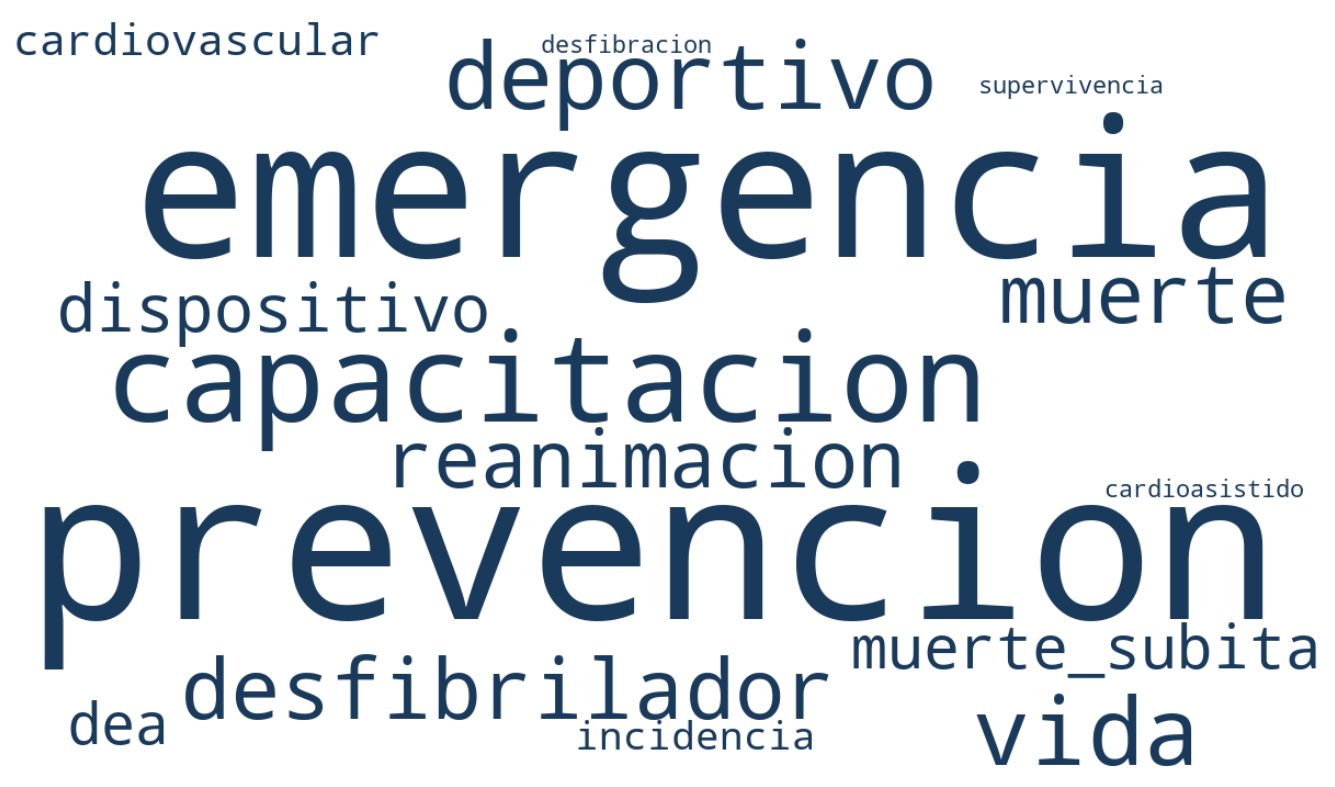

In [71]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Reemplazar frecuencias 0 por 1
frecuencias_wc = frecuencias_df['total'].replace(0, 1).to_dict()

wc = WordCloud(
    width=1200,
    height=700,
    background_color="white",
    prefer_horizontal=1.0, 
    collocations=False,
    max_words=100,
    color_func=lambda *args, **kwargs: "#1a3a5c"
).generate_from_frequencies(frecuencias_wc)

plt.figure(figsize=(14,8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.savefig(BASE_DIR+'imagenes/16_terminos_MS.png', dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()

In [21]:
frecuencias_df = salud_df[['Periodo']+ms_palabras].groupby(['Periodo']).sum().T#reset_index() # De los proyectos de ley de salyd

frecuencias_df['total'] = frecuencias_df.sum(axis=1)
display(frecuencias_df.sort_values('total', ascending=True))
frecuencias_df = frecuencias_df.sort_values('total', ascending=True).drop(columns='total')

# Cantidad de proyectos por periodo (para normalizar)
total_proyectos_por_anio = salud_df.groupby('Periodo').size()
print(total_proyectos_por_anio)
#frecuencia_df tiene palabras como índice y años como columnas (frecuencia absoluta)
frecuencia_relativa_df = frecuencias_df.div(total_proyectos_por_anio, axis=1) * 100  # multiplicamos por 100 para %

#frecuencia_relativa_df = frecuencias_df.div(frecuencias_df['total'], axis=0) * 100  # multiplicamos por 100 para %

# Ordenar por promedio total para ordenar mejor las barras
frecuencia_relativa_df['Promedio'] = frecuencia_relativa_df.mean(axis=1)
frecuencia_relativa_df = frecuencia_relativa_df.sort_values('Promedio', ascending=True).drop(columns='Promedio')

Periodo,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,total
desfibracion,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
cardioasistido,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
supervivencia,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
incidencia,0,0,0,0,0,0,1,0,0,2,0,1,0,0,0,4
cardiovascular,0,0,0,0,0,0,1,1,0,0,0,2,0,0,1,5
dea,0,0,0,0,1,1,2,0,0,0,2,2,1,0,0,9
muerte_subita,1,0,0,1,0,2,0,1,0,1,0,2,0,1,1,10
dispositivo,0,0,1,1,1,1,1,0,2,0,0,2,2,0,1,12
reanimacion,0,0,0,0,1,0,2,2,1,3,1,3,2,3,0,18
muerte,1,0,5,1,1,0,1,0,1,1,2,0,2,2,2,19


Periodo
127    151
128    164
129    144
130    150
131    167
132    225
133    182
134    196
135    181
136    225
137    225
138    345
139    171
140    187
141    135
dtype: int64


### Temporalidad del uso de términos vinculados a muerte súbita 
¿Qué tan frecuente es en la agenda?

In [22]:
frecuencia_relativa_df

Periodo,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141
desfibracion,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
cardioasistido,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
supervivencia,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
incidencia,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.549451,0.000000,0.000000,0.888889,0.000000,0.289855,0.000000,0.000000,0.000000
cardiovascular,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.549451,0.510204,0.000000,0.000000,0.000000,0.579710,0.000000,0.000000,0.740741
dea,0.000000,0.000000,0.000000,0.000000,0.598802,0.444444,1.098901,0.000000,0.000000,0.000000,0.888889,0.579710,0.584795,0.000000,0.000000
muerte_subita,0.662252,0.000000,0.000000,0.666667,0.000000,0.888889,0.000000,0.510204,0.000000,0.444444,0.000000,0.579710,0.000000,0.534759,0.740741
dispositivo,0.000000,0.000000,0.694444,0.666667,0.598802,0.444444,0.549451,0.000000,1.104972,0.000000,0.000000,0.579710,1.169591,0.000000,0.740741
reanimacion,0.000000,0.000000,0.000000,0.000000,0.598802,0.000000,1.098901,1.020408,0.552486,1.333333,0.444444,0.869565,1.169591,1.604278,0.000000
desfibrilador,0.000000,0.609756,1.388889,1.333333,1.197605,1.777778,1.098901,0.000000,1.104972,0.000000,1.333333,0.289855,0.584795,0.000000,0.000000


In [23]:
#  Calcular total por palabra (suma por fila)
frecuencias_df['total'] = frecuencias_df.sum(axis=1)
print(frecuencias_df)
# Crear distribución relativa por palabra
frecuencia_relativa_df2 = frecuencias_df.div(frecuencias_df['total'], axis=0) * 100

# Eliminar la columna total del resultado final
frecuencia_relativa_df2 = frecuencia_relativa_df2.drop(columns='total')

# Ordenar por total original (si querés mantener orden)
frecuencia_relativa_df2 = frecuencia_relativa_df2.loc[
    frecuencias_df.sort_values('total', ascending=True).index
]

Periodo         127  128  129  130  131  132  133  134  135  136  137  138  \
desfibracion      0    0    0    0    0    0    0    0    0    0    0    0   
cardioasistido    0    0    0    0    0    0    0    0    0    0    0    0   
supervivencia     0    0    0    0    0    0    0    0    0    0    0    0   
incidencia        0    0    0    0    0    0    1    0    0    2    0    1   
cardiovascular    0    0    0    0    0    0    1    1    0    0    0    2   
dea               0    0    0    0    1    1    2    0    0    0    2    2   
muerte_subita     1    0    0    1    0    2    0    1    0    1    0    2   
dispositivo       0    0    1    1    1    1    1    0    2    0    0    2   
reanimacion       0    0    0    0    1    0    2    2    1    3    1    3   
muerte            1    0    5    1    1    0    1    0    1    1    2    0   
desfibrilador     0    1    2    2    2    4    2    0    2    0    3    1   
deportivo         2    1    0    0    2    2    4    2    2    1

In [59]:
print(frecuencias_df)

Periodo         127  128  129  130  131  132  133  134  135  136  137  138  \
desfibracion      0    0    0    0    0    0    0    0    0    0    0    0   
cardioasistido    0    0    0    0    0    0    0    0    0    0    0    0   
supervivencia     0    0    0    0    0    0    0    0    0    0    0    0   
incidencia        0    0    0    0    0    0    1    0    0    2    0    1   
cardiovascular    0    0    0    0    0    0    1    1    0    0    0    2   
dea               0    0    0    0    1    1    2    0    0    0    2    2   
muerte_subita     1    0    0    1    0    2    0    1    0    1    0    2   
dispositivo       0    0    1    1    1    1    1    0    2    0    0    2   
reanimacion       0    0    0    0    1    0    2    2    1    3    1    3   
muerte            1    0    5    1    1    0    1    0    1    1    2    0   
desfibrilador     0    1    2    2    2    4    2    0    2    0    3    1   
deportivo         2    1    0    0    2    2    4    2    2    1

### ¿Cuándo se concentró su uso?

In [24]:
frecuencia_relativa_df2

Periodo,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141
desfibracion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cardioasistido,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
supervivencia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
incidencia,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,0.000000,50.000000,0.000000,25.000000,0.000000,0.000000,0.000000
cardiovascular,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,20.000000,0.000000,0.000000,0.000000,40.000000,0.000000,0.000000,20.000000
dea,0.000000,0.000000,0.000000,0.000000,11.111111,11.111111,22.222222,0.000000,0.000000,0.000000,22.222222,22.222222,11.111111,0.000000,0.000000
muerte_subita,10.000000,0.000000,0.000000,10.000000,0.000000,20.000000,0.000000,10.000000,0.000000,10.000000,0.000000,20.000000,0.000000,10.000000,10.000000
dispositivo,0.000000,0.000000,8.333333,8.333333,8.333333,8.333333,8.333333,0.000000,16.666667,0.000000,0.000000,16.666667,16.666667,0.000000,8.333333
reanimacion,0.000000,0.000000,0.000000,0.000000,5.555556,0.000000,11.111111,11.111111,5.555556,16.666667,5.555556,16.666667,11.111111,16.666667,0.000000
muerte,5.263158,0.000000,26.315789,5.263158,5.263158,0.000000,5.263158,0.000000,5.263158,5.263158,10.526316,0.000000,10.526316,10.526316,10.526316


In [25]:
frecuencia_relativa_df2 = frecuencia_relativa_df2.fillna(0)

In [26]:
frecuencia_relativa_df2[frecuencia_relativa_df2.sum(axis=1)>0].sum(axis=1)

incidencia        100.0
cardiovascular    100.0
dea               100.0
muerte_subita     100.0
dispositivo       100.0
reanimacion       100.0
muerte            100.0
desfibrilador     100.0
deportivo         100.0
vida              100.0
capacitacion      100.0
emergencia        100.0
prevencion        100.0
dtype: float64

In [27]:
frecuencia_relativa_df2.fillna(0).values.mean()


5.416666666666666

In [28]:
frecuencia_relativa_df2.columns # periodos

Index([127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140,
       141],
      dtype='object', name='Periodo')

In [29]:
frecuencia_relativa_df2

Periodo,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141
desfibracion,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
cardioasistido,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
supervivencia,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
incidencia,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,0.000000,50.000000,0.000000,25.000000,0.000000,0.000000,0.000000
cardiovascular,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,20.000000,0.000000,0.000000,0.000000,40.000000,0.000000,0.000000,20.000000
dea,0.000000,0.000000,0.000000,0.000000,11.111111,11.111111,22.222222,0.000000,0.000000,0.000000,22.222222,22.222222,11.111111,0.000000,0.000000
muerte_subita,10.000000,0.000000,0.000000,10.000000,0.000000,20.000000,0.000000,10.000000,0.000000,10.000000,0.000000,20.000000,0.000000,10.000000,10.000000
dispositivo,0.000000,0.000000,8.333333,8.333333,8.333333,8.333333,8.333333,0.000000,16.666667,0.000000,0.000000,16.666667,16.666667,0.000000,8.333333
reanimacion,0.000000,0.000000,0.000000,0.000000,5.555556,0.000000,11.111111,11.111111,5.555556,16.666667,5.555556,16.666667,11.111111,16.666667,0.000000
muerte,5.263158,0.000000,26.315789,5.263158,5.263158,0.000000,5.263158,0.000000,5.263158,5.263158,10.526316,0.000000,10.526316,10.526316,10.526316


In [30]:
# Calcular total absoluto por palabra
frecuencias_df['total'] 

desfibracion        0
cardioasistido      0
supervivencia       0
incidencia          4
cardiovascular      5
dea                 9
muerte_subita      10
dispositivo        12
reanimacion        18
muerte             19
desfibrilador      20
deportivo          25
vida               26
capacitacion       48
emergencia        171
prevencion        204
Name: total, dtype: int64

In [31]:
# Controlando el peso de emergencia y prevención
peso = 523 - (171+204)
print('peso',peso,((peso/2848)*100))

peso 148 5.196629213483146


#### Figura 5.1 

Se identificaron 523 proyectos de ley sobre salud que incluyen al menos un término asocia-
do a la prevención de la muerte súbita, lo que representa el 18,36 % del total de iniciativas
sobre salud para el período analizado. No obstante, al excluir términos de carácter general
como emergencia y prevencion, la proporción se reduce al 5,37 %, lo que evidencia una
visibilidad temática limitada del vocabulario específico en los títulos legislativos.
El análisis de la distribución temporal se realizó a partir de la frecuencia relativa de
cada término respecto de su frecuencia absoluta total en el corpus. Esta medida permite
responder a la pregunta: ¿en qué períodos parlamentarios se concentró el uso de cada
término? Los resultados muestran que el período parlamentario 138 registra la mayor
concentración relativa de términos asociados a muerte súbita, mientras que el período
128 presenta una presencia comparativamente menor.

6.666666666666667


C:\Users\Usuario\AppData\Local\Temp\ipykernel_12328\1458007527.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = annot_text.applymap(


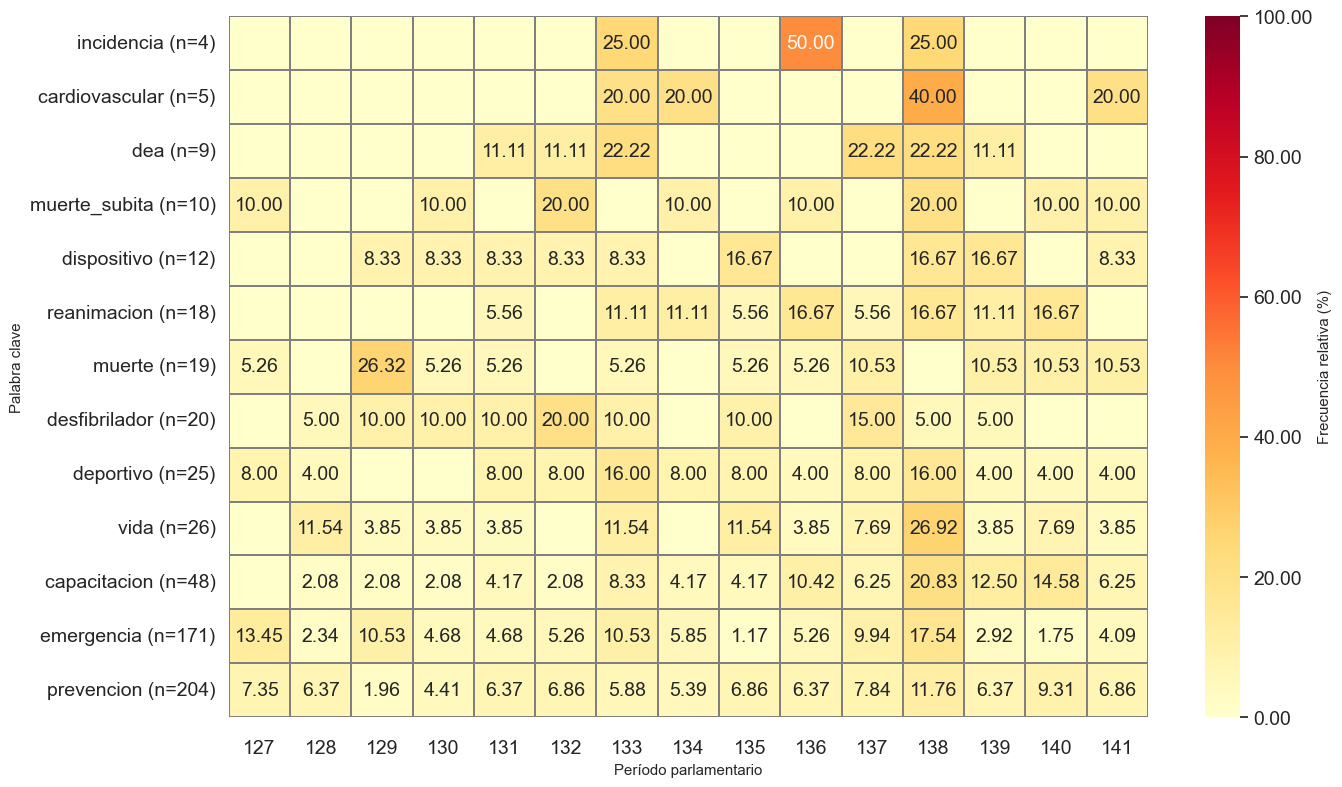

In [57]:
import matplotlib.ticker as mticker

plt.figure(figsize=(14, 8))
sns.set(font_scale=0.9)

# Crear matriz de anotaciones personalizada
annot_text = frecuencia_relativa_df2[frecuencia_relativa_df2.sum(axis=1)>0].copy()
frec = frecuencia_relativa_df2[frecuencia_relativa_df2.sum(axis=1)>0].copy()
mean = annot_text.fillna(0).values.mean()
print(mean)


# Condición: mostrar solo valores > 1
annot_text = annot_text.applymap(
    lambda x: f"{locale.format_string('%.2f', x)}"  if x > 0  else ""
)

# Heatmap
ax= sns.heatmap(
    frec,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor='gray',
    cbar_kws={'label': 'Frecuencia relativa (%)'},
    vmin=0,
    vmax=100,
    annot=annot_text,
    fmt='',
    annot_kws={"size": 14}  # Tamaño del texto en celdas
)

# ==============================
# FORMATEAR COLORBAR
# ==============================

cbar = ax.collections[0].colorbar

# Función de formateo con locale
def formato_colorbar(x, pos):
    return f'{x:.2f}'#locale.format_string('%.2f', x)

cbar.ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(formato_colorbar)
)

cbar.ax.tick_params(labelsize=14)

# ==============================

ax.set_xlabel('Período parlamentario')
ax.set_ylabel('Palabra clave')
ax.tick_params(axis='x', which='major', labelsize=14, pad=10)  # Más espacio entre labels y eje
ax.tick_params(axis='y', labelsize=14)

# Convertir etiquetas de período
xtick_labels = [periodos_a_fechas(x) for x in frec.columns]

ax.set_xticklabels(
     frec.columns, #xtick_labels,
    #rotation=20,
    #ha='right',
    fontsize=14
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontsize=14
)

# Calcular total absoluto por palabra
totales = frecuencias_df['total'] 

# Crear nuevas etiquetas
nuevas_etiquetas = [
    f"{palabra} (n={totales.loc[palabra]})"
    for palabra in frec.index
]

ax.set_yticklabels(nuevas_etiquetas, fontsize=14)

#plt.title('Frecuencia relativa de los 20 términos asociados a "muerte súbita" en Proyectos de ley sobre salud en los períodos parlamentario 127 - 141 (2009–2024)', fontsize=14)
plt.savefig(BASE_DIR+'imagenes/Frecuencia relativa de los 20 términos asociados.png', dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

In [33]:
frecuencia_relativa_df2.sum(axis=0)

Periodo
127     44.066391
128     31.333525
129     63.065710
130     48.616106
131     67.326890
132     81.653681
133    154.210288
134     64.517888
135     69.222844
136    111.828352
137     93.031059
138    238.620531
139     84.057884
140     74.536735
141     73.912115
dtype: float64

In [58]:
frecuencia_relativa_df2[frecuencia_relativa_df2.sum(axis=1)>0].copy()

Periodo,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141
incidencia,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,0.000000,50.000000,0.000000,25.000000,0.000000,0.000000,0.000000
cardiovascular,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,20.000000,0.000000,0.000000,0.000000,40.000000,0.000000,0.000000,20.000000
dea,0.000000,0.000000,0.000000,0.000000,11.111111,11.111111,22.222222,0.000000,0.000000,0.000000,22.222222,22.222222,11.111111,0.000000,0.000000
muerte_subita,10.000000,0.000000,0.000000,10.000000,0.000000,20.000000,0.000000,10.000000,0.000000,10.000000,0.000000,20.000000,0.000000,10.000000,10.000000
dispositivo,0.000000,0.000000,8.333333,8.333333,8.333333,8.333333,8.333333,0.000000,16.666667,0.000000,0.000000,16.666667,16.666667,0.000000,8.333333
reanimacion,0.000000,0.000000,0.000000,0.000000,5.555556,0.000000,11.111111,11.111111,5.555556,16.666667,5.555556,16.666667,11.111111,16.666667,0.000000
muerte,5.263158,0.000000,26.315789,5.263158,5.263158,0.000000,5.263158,0.000000,5.263158,5.263158,10.526316,0.000000,10.526316,10.526316,10.526316
desfibrilador,0.000000,5.000000,10.000000,10.000000,10.000000,20.000000,10.000000,0.000000,10.000000,0.000000,15.000000,5.000000,5.000000,0.000000,0.000000
deportivo,8.000000,4.000000,0.000000,0.000000,8.000000,8.000000,16.000000,8.000000,8.000000,4.000000,8.000000,16.000000,4.000000,4.000000,4.000000
vida,0.000000,11.538462,3.846154,3.846154,3.846154,0.000000,11.538462,0.000000,11.538462,3.846154,7.692308,26.923077,3.846154,7.692308,3.846154


¿Los proyectos sobre muerte súbita siguen el mismo circuito institucional que el resto de proyectos de salud o tienen una trayectoria diferenciada?

In [34]:
# CATEGORÍA A COMPARAR, por ejemplo: Tipo de proyecto
cat_var = "Resultado"  # puede ser 'Resultado', 'Tiene_antecedente', etc.

# Función para obtener distribución porcentual
def get_category_distribution(df, label):
    distrib = df[cat_var].value_counts(normalize=True).rename_axis('Categoria').reset_index(name=label)
    return distrib

# Calcular distribuciones
dist_total = get_category_distribution(total_df, "Total de proyectos")
dist_ley = get_category_distribution(ley_df, "Proyectos de Ley")
dist_salud = get_category_distribution(salud_df, "Proyectos de Salud")
dist_muerte = get_category_distribution(ms_df, "Proyectos de Muerte súbita")

# Combinar todas
df_comb = dist_total.merge(dist_ley, on="Categoria", how="outer").merge(dist_salud, on="Categoria", how="outer").merge(dist_muerte, on="Categoria", how="outer").set_index("Categoria")
numeric_cols_filled = df_comb.select_dtypes(include=['number']).fillna(0) # valores vacios
# Update 
df_comb.update(numeric_cols_filled)

df_comb = df_comb * 100  # pasar a %
df_comb

,Total de proyectos,Proyectos de Ley,Proyectos de Salud,Proyectos de Muerte súbita
Categoria,,,,
APROBADO,12.488248,0.024171,0.000000,0.000000
MEDIA SANCION,1.027719,2.474545,2.808989,1.912046
NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,86.374885,97.262592,96.875000,98.087954
RECHAZADO,0.003242,0.000000,0.000000,0.000000
RETIRADO,0.003242,0.009064,0.000000,0.000000
SANCIONADO,0.046469,0.099707,0.175562,0.000000
SIN INFORMACIÓN DE RESULTADO DE PROYECTO,0.056195,0.129921,0.140449,0.000000


#### Comisiones Normalizadas

In [35]:
# Abrir
with open(RESULTADOS_DIR+'comisionNorm_proyectoid.pkl', 'rb') as file:
    temp2_df = pickle.load(file)

temp2_df.describe(include='all').T

,count,unique,top,freq
Proyecto.ID,400540,267339,HCDN006292,11
comision_nombre_normalizada_Levenshtein,400540,148,presupuesto y hacienda,47388


¿Los proyectos de muerte súbita pasan por menos comisiones? ¿Por comisiones más específicas?

In [36]:
ley_df.shape # cantidad de proyectos de ley

(33097, 40)

In [37]:
salud_df.shape # cantidad de proyectos de salud

(2848, 40)

In [38]:
ley_df['Proyecto_MS'] = 0
ley_df.loc[ley_df['Proyecto.ID'].isin(list(ms_df['Proyecto.ID'].values)), 'Proyecto_MS'] = 1

In [39]:
ley_com_df = pd.merge(ley_df,temp2_df, how ='inner', left_on = 'Proyecto.ID', right_on = 'Proyecto.ID')
ley_com_df.shape

(74175, 42)

In [40]:
pickle.dump(ley_df, open(RESULTADOS_DIR +'ley_df.pkl', 'wb'))
pickle.dump(ley_com_df, open(RESULTADOS_DIR +'ley_com_df.pkl', 'wb'))

In [41]:
ley_df[ley_df['Proyecto_SALUD']==1].shape #  Control 

(2848, 41)

In [42]:
ley_df[ley_df['Proyecto_MS']==1].shape #  Control 

(523, 41)

In [43]:
ley_df.columns

Index(['Proyecto.ID', 'Título', 'Publicación.Fecha', 'Publicación.ID',
       'Exp..Diputados', 'Tipo', 'Max_Orden',
       'Proyecto_girado_a_comisiones_SALUD', 'Proyecto_SALUD', 'Resultado',
       'Tiene_info_movimiento', 'Duración_dias_prep', 'Años_mes', 'Año', 'Mes',
       'Nombre_dia_semana', 'Tiempo_desde_public_anterior',
       'Tiempo_desde_Proyecto.ID_anterior', 'ID', 'Diferencia_ID',
       'Tiene_antecedente_por_titulo_proy', 'Fecha', 'Periodo',
       'Título normalizado', 'muerte_subita', 'desfibrilador', 'desfibracion',
       'cardiovascular', 'cardioasistido', 'dea', 'dispositivo', 'muerte',
       'vida', 'capacitacion', 'emergencia', 'supervivencia', 'reanimacion',
       'prevencion', 'incidencia', 'deportivo', 'Proyecto_MS'],
      dtype='object')

¿Los proyectos de salud tienen mayor recorrido institucional que el resto?

In [44]:
from scipy import stats

salud = ley_df[ley_df["Proyecto_SALUD"] == 1]["Max_Orden"].dropna()
no_salud = ley_df[ley_df["Proyecto_SALUD"] == 0]["Max_Orden"].dropna()

stats.shapiro(salud)
stats.shapiro(no_salud)

C:\Users\Usuario\iamas_iniciativasleg_salud\myenv_IL\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 30249.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=0.8603756722025595, pvalue=8.456212248719142e-94)

Shapiro-Wilk devuelve:

estadístico W

p-value

Interpretación:

p > .05 → no se rechaza normalidad (aprox. normal)

p < .05 → distribución no normal

Con muestras grandes (n > 50), Shapiro casi siempre da significativo aunque la distribución sea razonable.

Por eso no alcanza solo con el test.

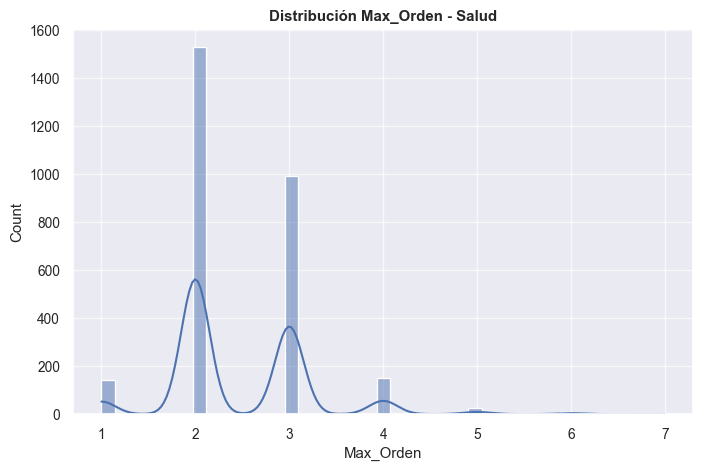

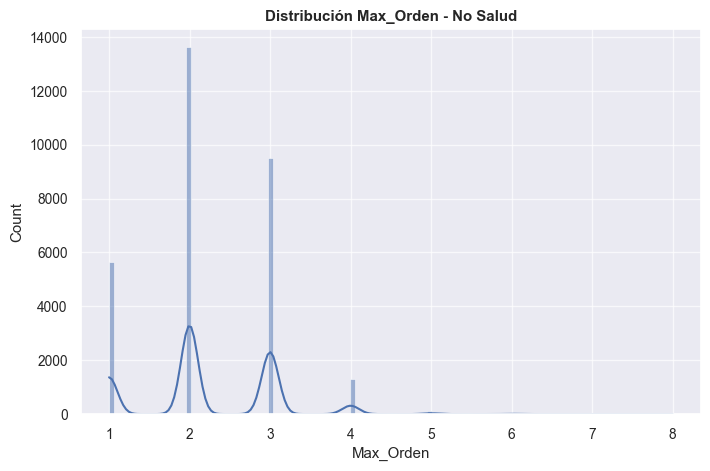

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(salud, kde=True)
plt.title("Distribución Max_Orden - Salud")
plt.show()

sns.histplot(no_salud, kde=True)
plt.title("Distribución Max_Orden - No Salud")
plt.show()

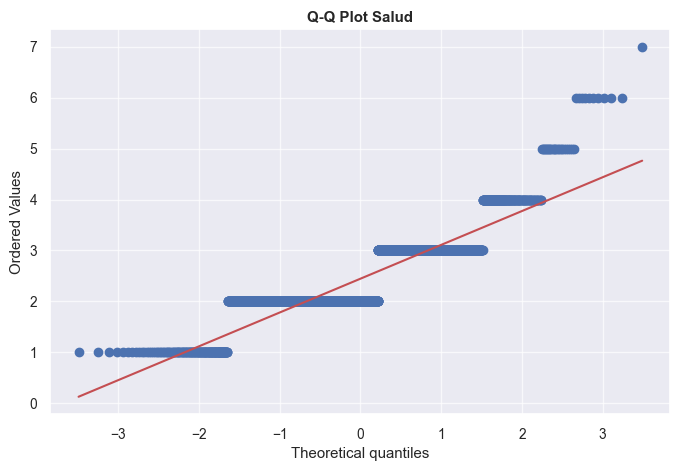

In [46]:
# Q-Q plot para Salud
stats.probplot(salud, dist="norm", plot=plt)
plt.title("Q-Q Plot Salud")
plt.show() ## Si el Q-Q se desvía mucho de la línea → no normal

In [47]:
#### Distribución no normal
#Interpretación:
#Si p < .05 → diferencia significativa en distribución de complejidad institucional.
#Es más apropiado para:
#Datos ordinales
#Asimetría
#Colas largas
stats.mannwhitneyu(salud, no_salud, alternative="two-sided")

MannwhitneyuResult(statistic=48758743.5, pvalue=5.4417431462195135e-36)

¿Los proyectos de muerte súbita son más reiterados que el resto?

In [48]:
## Tabla de contigencia
tabla1 = pd.crosstab(
    ley_df["Proyecto_SALUD"],
    ley_df["Tiene_antecedente_por_titulo_proy"]
)

tabla1

Tiene_antecedente_por_titulo_proy,False,True
Proyecto_SALUD,,
0.0,28693,1556
1.0,2722,126


In [49]:
tabla1_prop = pd.crosstab(
    ley_df["Proyecto_SALUD"],
    ley_df["Tiene_antecedente_por_titulo_proy"],
    normalize="index"
)

tabla1_prop

Tiene_antecedente_por_titulo_proy,False,True
Proyecto_SALUD,,
0.0,0.948560,0.051440
1.0,0.955758,0.044242


In [50]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla1)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 2.6486427373914907
p-value: 0.10363834943186231


p < .05 → existe asociación significativa entre tipo de proyecto y reiteración

p ≥ .05 → no hay evidencia de diferencia

#### Muerte subita

In [51]:
df_salud = ley_df[ley_df["Proyecto_SALUD"] == 1].copy()


In [52]:
tabla2 = pd.crosstab(
    df_salud["Proyecto_MS"],
    df_salud["Tiene_antecedente_por_titulo_proy"]
)
tabla2

Tiene_antecedente_por_titulo_proy,False,True
Proyecto_MS,,
0,2221,104
1,501,22


In [53]:
tabla2_prop = pd.crosstab(
    df_salud["Proyecto_MS"],
    df_salud["Tiene_antecedente_por_titulo_proy"],
    normalize="index"
)

tabla2_prop

Tiene_antecedente_por_titulo_proy,False,True
Proyecto_MS,,
0,0.955269,0.044731
1,0.957935,0.042065


In [54]:
chi2, p, dof, expected = chi2_contingency(tabla2)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 0.02257066893754448
p-value: 0.8805789146737951


In [55]:
ley_df['Resultado'].unique()

['NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN', 'MEDIA SANCION', 'SIN INFORMACIÓN DE RESULTADO DE PROYECTO', 'SANCIONADO', 'RETIRADO', 'APROBADO']
Categories (7, object): ['APROBADO', 'MEDIA SANCION', 'NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN', 'RECHAZADO', 'RETIRADO', 'SANCIONADO', 'SIN INFORMACIÓN DE RESULTADO DE PROYECTO']

In [56]:
df["Avanza"] = df["Resultado"].isin(
    ["aprobado", "media sancion", "sancion"]
).astype(int)

NameError: name 'df' is not defined

No se observaron diferencias estadísticamente significativas...

In [ ]:
ley_com_df = pd.merge(ley_df,temp2_df, how ='inner', left_on = 'Proyecto.ID', right_on = 'Proyecto.ID')
ley_com_df.shape

In [ ]:
ley_com_df.describe(include = 'all').T

In [ ]:
ley_com_df.columns

In [ ]:
# Comisiones ordenadas por % de intervenciones en proyectos sobre salud
ley_com_df['comision_nombre_normalizada_Levenshtein'].value_counts( normalize=True )#.head((10)

In [ ]:
ley_com_df["ms_palabras"] = 0
ley_com_df.loc[(ley_com_df["Título normalizado"].str.contains(pattern, case=False, na=False) ) & (ley_com_df['Proyecto_SALUD']==1), "ms_palabras"]=1 

In [ ]:
ley_com_df['ms_palabras'].sum() # Controlar proyectos asociados con MUERTE SUBITA

In [ ]:
# Dataset base
df = ley_com_df.copy()

# --- Subconjuntos ---
df_all = ley_com_df
df_salud = df[df["Proyecto_SALUD"] == 1]
df_ms = df[df["ms_palabras"] == 1]

def comisiones_stats(subset, name):
    total = len(subset)

    # Frecuencia absoluta por comisión
    freq_abs = (
        subset.groupby("comision_nombre_normalizada_Levenshtein")
              .size()
              .sort_values(ascending=False)
    )

    # Frecuencia relativa (%)
    freq_rel = ((freq_abs / total) * 100).round(2)

    print(f"\n===== {name} =====")
    print(f"N proyectos: {total}\n")

    print("📌 Top 10 comisiones (Frecuencia absoluta):")
    print(freq_abs.head(10), "\n")
    
    print("📌 Top 10 comisiones (Frecuencia relativa %):")
    print(freq_rel.head(10))
    
    return freq_abs, freq_rel

# --- Ejecutar reportes ---
com_all_abs, com_all_rel = comisiones_stats(df_all, "TODOS los Proyectos")
com_salud_abs, com_salud_rel = comisiones_stats(df_salud, "Proyectos de SALUD")
com_ms_abs, com_ms_rel = comisiones_stats(df_ms, "Proyectos MUERTE SÚBITA")


In [ ]:
# Tomar el índice base
com_all_top10 = com_all_rel.sort_values(ascending=False).head(10)
idx = com_all_top10.index

# Reindexar los otros (rellenando con 0 si no existen)
com_salud_rel = com_salud_rel.reindex(idx, fill_value=0)
com_ms_rel = com_ms_rel.reindex(idx, fill_value=0)

In [ ]:
# Paleta
color_all = GRAY_MAIN  # gris
color_salud = HEALTH_CYAN # celeste
color_ms = "#003F5C"   # azul fuerte


# Frecuencias relativas (ya calculadas antes)
x = range(len(com_all_top10.index))
width = 0.27

fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')

# Crear las barras
ax.bar([i - width for i in x], com_all_top10.values, width, color=color_all, label="Todos los proyectos de ley")
ax.bar(x, com_salud_rel.values, width, color=color_salud, label="Salud")
ax.bar([i + width for i in x], com_ms_rel.values, width, color=color_ms, label="Muerte Súbita")

# Configurar el gráfico sin grid
ax.set_xticks(x)
ax.set_xticklabels(com_all_top10.index, rotation=45, ha='right',fontsize=14)
ax.tick_params(axis='x', which='major', labelsize=14, pad=10)  # Más espacio entre labels y eje
ax.tick_params(axis='y', labelsize=14)
#ax.set_title("Top 10 Comisiones por Frecuencia Relativa (%) en donde giran los Proyectos de ley", pad=20, fontsize=14)
ax.set_ylabel("Porcentaje de Proyectos (%)", fontsize=14, fontweight='bold', labelpad=20)

    
# ----- LIMPIAR ESTÉTICA -----
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

# Leyenda centrada debajo del título del primer eje
handles, labels = ax.get_legend_handles_labels()

legend  = ax.legend(handles, labels,
             loc='upper center',
             bbox_to_anchor=(0.5, 1.12),  # justo debajo del título
             ncol=3,
             fontsize=18,
             frameon=False)
legend.get_frame().set_linewidth(0)
legend.get_frame().set_edgecolor("none")
legend.get_frame().set_facecolor("none")

# Fondo blanco del área del gráfico
ax.set_facecolor('white')
# Guardar y mostrar
plt.savefig(BASE_DIR+'imagenes/top10comisiones.png', 
            dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

In [ ]:
com_all_top10 

In [ ]:
com_salud_rel 


In [ ]:
com_ms_rel 